# Combining images

### We can increase signal to noise by combining images (sum, average, median)

### Consider summing three images with the same Gaussian noise properties

### The signal increases linearly if we sum

### Gaussian noise adds in quadrature so...

\begin{equation}
\sigma_1 = \sigma_2 = \sigma_3 
\end{equation}

\begin{equation}
\sigma_{sum}^2 = \sigma_1^2 + \sigma_2^2 + \sigma^3_3
\end{equation}

\begin{equation}
\sigma_{sum} = \sqrt{3} \times \sigma_1
\end{equation}

### If we do an average instead of a sum then the noise stays about the same while the noise.... 

\begin{equation}
\sigma_{av} = \frac{\sqrt{3}}{3} \times \sigma_1
\end{equation}

### So, when we average N images together the noise decreases by the sqaure root of N

### Let's first test how the noise behaves with bias images 

###

In [1]:
# To use astropy we need to import libraries 


import numpy as np
import astropy
import photutils
import ccdproc
from ccdproc import CCDData, combiner
from astropy import units as u
import astropy.io.fits as fits
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.time import Time
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm
from scipy.ndimage import shift

import os
import gc             

# Read in bias images 

In [2]:
images = ccdproc.ImageFileCollection('./',glob_include = 'Bias*fits')
for filename in images.files_filtered():
    print(filename)

# Load all of the images in the list 

bias=[]
for filename in images.files_filtered():
    bias.append(CCDData.read(filename, unit = "adu"))


Set OBSGEO-Y to  2879792.379 from OBSGEO-[LBH].
Set OBSGEO-Z to -3897419.410 from OBSGEO-[LBH]'. [astropy.wcs.wcs]
Set OBSGEO-Y to  2879792.379 from OBSGEO-[LBH].
Set OBSGEO-Z to -3897419.410 from OBSGEO-[LBH]'.


Bias_00002830.fits
Bias_00002835.fits
Bias_00002840.fits
Bias_00002845.fits
Bias_00002850.fits


In [3]:
# Lets average the images together 

# Create a bias image which initally is a copy of the first image 
biasav=bias[0].data

# Add the other bias images to it
idx=1
while idx<len(bias):
    biasav=biasav+bias[idx].data
    idx=idx+1

# Divide by the number of images 
biasav=biasav/idx

1913.0
1831.0 2018.0


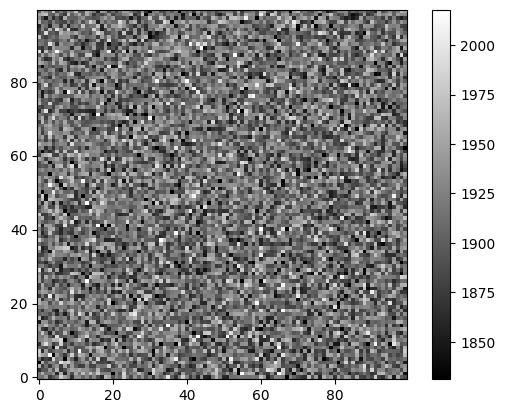

In [4]:
# Zoom in on region in the first bias frame and display

idx=0  # Index
med=np.median(bias[idx].data)
print(med)
p1=np.percentile(bias[idx].data, 1)
p99=np.percentile(bias[idx].data, 99)
print(p1,p99)

skydata=bias[idx].data[845:945,250:350]

plt.imshow(skydata, cmap='gray', vmin=p1, vmax=p99)
ax = plt.gca()
ax.invert_yaxis()
plt.colorbar(shrink=1.0)

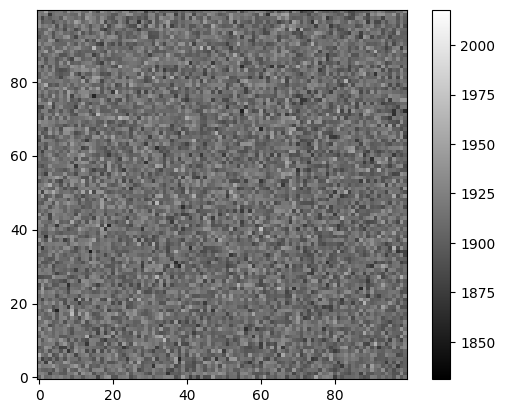

In [5]:
# Zoom in on the same region in the average bias 

skydata=biasav[845:945,250:350]

plt.imshow(skydata, cmap='gray', vmin=p1, vmax=p99)
ax = plt.gca()
ax.invert_yaxis()
plt.colorbar(shrink=1.0)

# Comparison of standard deviation measured across entire images 

In [6]:
bstd=[]
for im in bias:
    bstd.append(np.std(im.data))
print('Standard deviations of the individal bias images:\n ', bstd)
print('\n\n')

stdav=np.std(biasav)
print('Standard deviations of the average of the bias images: ', stdav)
print('\n\n')

print('Standard deviations of the average of the bias images multiplied by root N: ', stdav*len(bstd)**0.5)


Standard deviations of the individal bias images:
  [np.float64(39.09426106853241), np.float64(39.10805247514428), np.float64(39.03314651738812), np.float64(39.00574307933763), np.float64(38.96346684029156)]



Standard deviations of the average of the bias images:  24.15941489134402



Standard deviations of the average of the bias images multiplied by root N:  54.022093993665926


# Comparison of standard deviation measured across subsections of images 


In [7]:
bstd=[]
for im in bias:
    bstd.append(np.std(im.data[300:400,300:400]))
print('Standard deviations of the individal bias images (subsection):\n ', bstd)
print('\n\n')

stdav=np.std(biasav[300:400,300:400])
print('Standard deviations of the average of the bias images (subsection): ', stdav)
print('\n\n')

print('Standard deviations of the average of the bias images multiplied by root N (subsection): ', stdav*len(bstd)**0.5)


Standard deviations of the individal bias images (subsection):
  [np.float64(33.67897140219695), np.float64(33.79505204256978), np.float64(33.898212719257046), np.float64(33.974386137795044), np.float64(33.827620570179036)]



Standard deviations of the average of the bias images (subsection):  15.200216753599273



Standard deviations of the average of the bias images multiplied by root N (subsection):  33.98871793377915


# Comment

### Why are the stats different for the whole image and for subsections?

### When we combine images, why don't the stats for the whole combined image match expectations?

### When we combine images, why do the stats for the subsection of the combined image match expections?

### What does the standard deviation or RMS measure on the whole image and a subsection?

###

# Lets take a look at the whole combined image

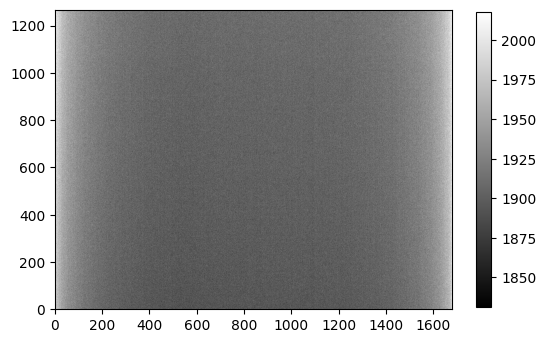

In [8]:
# Zoom in on the same region in the average bias 

skydata=biasav

plt.imshow(skydata, cmap='gray', vmin=p1, vmax=p99)
ax = plt.gca()
ax.invert_yaxis()
plt.colorbar(shrink=0.8)

# CCDproc 

### So far I've done a series of tasks with maths directly 

### However, CCDproc has functions to do this for us 

### Let's use ccdproc.combine


In [9]:
biasav_proc = ccdproc.combine(bias, method='average', sigma_clip=False)

stdavp=np.std(biasav_proc.data[300:400,300:400])
print('Standard deviation of the average of the bias images (subsection): ', stdav)


Standard deviation of the average of the bias images (subsection):  15.200216753599273


### Let's do a median combine 


In [10]:

biasme_proc = ccdproc.combine(bias, method='median', sigma_clip=False)

stdmep=np.std(biasme_proc.data[300:400,300:400])
print('Standard deviation of the median of the bias images (subsection): ', stdmep)


Standard deviation of the median of the bias images (subsection):  18.263626530347143


Text(0.5, 1.0, 'Average combine')

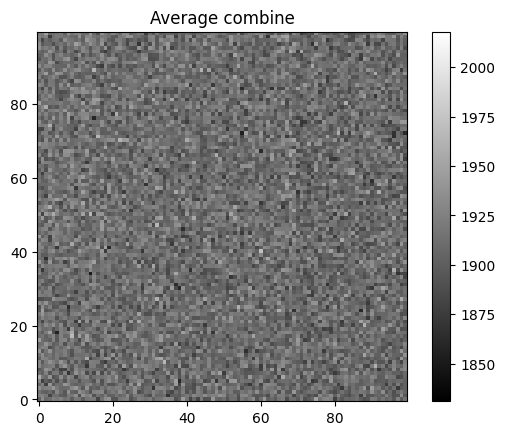

In [11]:
# Zoom in on the same region in the average bias 

skydata=biasav_proc.data[845:945,250:350]

plt.imshow(skydata, cmap='gray', vmin=p1, vmax=p99)
ax = plt.gca()
ax.invert_yaxis()
plt.colorbar(shrink=1.0)
plt.title('Average combine')

Text(0.5, 1.0, 'Median combine')

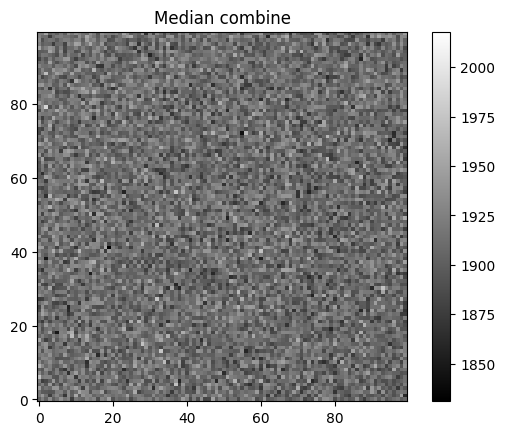

In [12]:
# Zoom in on the same region in the median bias 

skydata=biasme_proc.data[845:945,250:350]

plt.imshow(skydata, cmap='gray', vmin=p1, vmax=p99)
ax = plt.gca()
ax.invert_yaxis()
plt.colorbar(shrink=1.0)
plt.title('Median combine')